In [2]:
# uci_har_prototype.py
# UCI HAR baseline prototype - 6-class model for domain validation only.

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

from google.colab import drive

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

# Confirm project folder accessibility in My Drive
#print(os.listdir('/content/drive/My Drive/AG/FH/study/AI_IoT/node/milestone2/UCI-HAR_Dataset'))



Mounted at /content/drive


In [20]:
# Declare project home directory
project_path = "/content/drive/My Drive/AG/FH/study/AI_IoT/node/milestone2"
os.makedirs(project_path, exist_ok=True)

# Create output directory
os.makedirs(f"{project_path}/output", exist_ok=True)
os.makedirs(f"{project_path}/output/models", exist_ok=True)

In [5]:
# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

TARGET_NAMES = ["WALKING", "WALKING_UP", "WALKING_DOWN", "SITTING", "STANDING", "LAYING"]
NUM_CLASSES  = 6

In [6]:
# ── Data loading ──────────────────────────────────────────────────────────────
def load_uci_har_raw(data_path=f"{project_path}/UCI-HAR_Dataset"):
    acc_axes  = ["body_acc_x",  "body_acc_y",  "body_acc_z"]
    gyro_axes = ["body_gyro_x", "body_gyro_y", "body_gyro_z"]

    def _load_split(split):
        arrays = []
        for name in acc_axes + gyro_axes:
            path = f"{data_path}/{split}/InertialSignals/{name}_{split}.txt"
            arrays.append(np.loadtxt(path))
        return np.stack(arrays, axis=-1)

    X_train = _load_split("train")
    X_test  = _load_split("test")

    y_train = np.loadtxt(f"{data_path}/train/y_train.txt", dtype=int)
    y_test  = np.loadtxt(f"{data_path}/test/y_test.txt", dtype=int)

    y_train -= 1
    y_test  -= 1

    return X_train, y_train, X_test, y_test

In [7]:
# ── Feature extraction ────────────────────────────────────────────────────────
def extract_features_window(window):
    feats = []
    for axis in range(6):
        feats.append(np.mean(window[:, axis]))
        feats.append(np.std(window[:, axis]))
    for axis in range(6):
        feats.append(np.min(window[:, axis]))
        feats.append(np.max(window[:, axis]))

    feats.append(np.sum(np.abs(window[:, :3])) / window.shape[0])
    feats.append(np.sum(np.abs(window[:, 3:])) / window.shape[0])

    acc_mag = np.linalg.norm(window[:, :3], axis=1)
    feats.append(np.mean(acc_mag))
    feats.append(np.std(acc_mag))

    return np.array(feats)

In [8]:
# ── Main ──────────────────────────────────────────────────────────────────────
X_train_raw, y_train, X_test_raw, y_test = load_uci_har_raw()

X_train_feat = np.array([extract_features_window(w) for w in X_train_raw])
X_test_feat  = np.array([extract_features_window(w) for w in X_test_raw])

print(f"Feature shape - train: {X_train_feat.shape}, test: {X_test_feat.shape}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_feat)
X_test_sc  = scaler.transform(X_test_feat)

model = models.Sequential([
    layers.Input(shape=(X_train_feat.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="uci_har_baseline")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_sc, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_sc, y_test),
    callbacks=[early_stop],
    verbose=1,
)

Feature shape - train: (7352, 28), test: (2947, 28)


Model: "uci_har_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,126 (4.40 KB)

 Trainable params: 1,126 (4.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3796 - loss: 1.2321 - val_accuracy: 0.4601 - val_loss: 1.0617
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5037 - loss: 0.9765 - val_accuracy: 0.5436 - val_loss: 0.9459
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5696 - loss: 0.8775 - val_accuracy: 0.5792 - val_loss: 0.8741
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6032 - loss: 0.8159 - val_accuracy: 0.6074 - val_loss: 0.8264
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6250 - loss: 0.7761 - val_accuracy: 0.6254 - val_loss: 0.7936
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6455 - loss: 0.7477 - val_accuracy: 0.6369 - val_loss: 0.7683
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6612 - loss: 0.7261 - val_accuracy: 0.6474 - val_loss: 0.7482
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6715 - loss: 0.7082 - val_accuracy: 0.

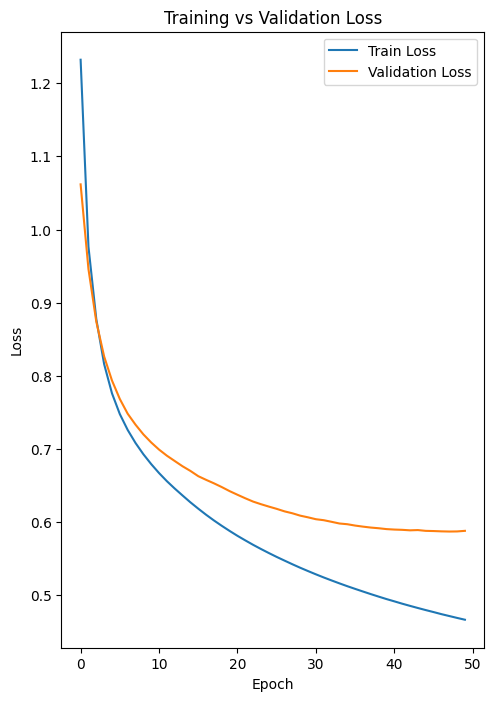

In [9]:
# ── Plot Training vs Validation Loss & Accuracy ───────────────────────────────
plt.figure(figsize=(12,8))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{project_path}/output/training_validation_curves.png", dpi=150)
plt.show()

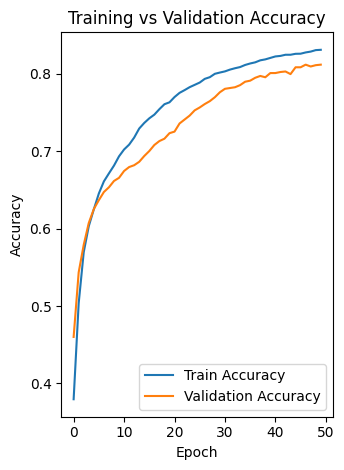

Saved training_curves.png


In [10]:
# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(f"{project_path}/output/training_curves.png", dpi=150)
plt.show()

print("Saved training_curves.png")



93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

              precision    recall  f1-score   support

     WALKING       0.84      0.83      0.84       496
  WALKING_UP       0.79      0.83      0.81       471
WALKING_DOWN       0.92      0.88      0.90       420
     SITTING       0.78      0.68      0.73       491
    STANDING       0.86      0.74      0.80       532
      LAYING       0.72      0.90      0.80       537

    accuracy                           0.81      2947
   macro avg       0.82      0.81      0.81      2947
weighted avg       0.81      0.81      0.81      2947



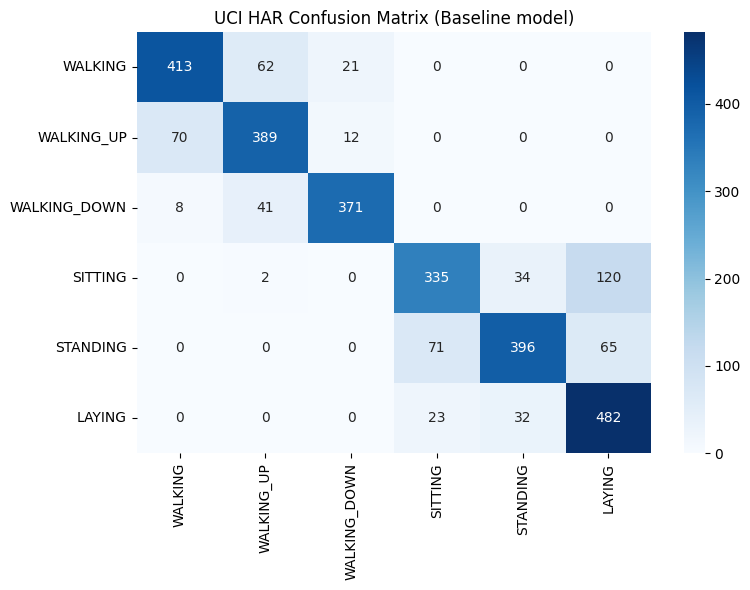

Saved uci_har_confusion_matrix.png


In [11]:

# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(X_test_sc), axis=1)

print("\n" + classification_report(y_test, y_pred, target_names=TARGET_NAMES))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=TARGET_NAMES,
            yticklabels=TARGET_NAMES,
            cmap="Blues")

plt.title("UCI HAR Confusion Matrix (Baseline model)")
plt.tight_layout()
plt.savefig(f"{project_path}/output/uci_har_confusion_matrix.png", dpi=150)
plt.show()

print("Saved uci_har_confusion_matrix.png")

In [21]:
# ── Save Model ────────────────────────────────────────────────────────────────
model.save(f"{project_path}/output/models/uci_har_baseline.keras")
print("Saved uci_har_baseline.keras")

Saved uci_har_baseline.keras


In [19]:
# ── 1. Label Mapping (6 → 2 classes) ──────────────────────────
# 0: stationary, 1: walking

def map_labels(y):
    mapped = []
    for label in y:
        if label in [0, 1, 2]:      # WALKING variants
            mapped.append(1)        # walking
        elif label in [3, 4, 5]:    # SITTING/STANDING/LAYING
            mapped.append(0)        # stationary
    return np.array(mapped)

y_train_mapped = map_labels(y_train)
y_test_mapped  = map_labels(y_test)

TARGET_NAMES_REDUCED = ["STATIONARY", "WALKING"]

print("Original classes:", np.unique(y_train))
print("Mapped classes:", np.unique(y_train_mapped))

Original classes: [0 1 2 3 4 5]
Mapped classes: [0 1]


In [14]:
# ── 2. Build Reduced Model ────────────────────────────────────
model_reduced = models.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(2, activation="softmax"),
], name="uci_har_reduced_baseline")

model_reduced.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_reduced.summary()

Model: "uci_har_reduced_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994 (3.88 KB)

 Trainable params: 994 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ── 3. Train ──────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_reduced = model_reduced.fit(
    X_train_sc, y_train_mapped,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_sc, y_test_mapped),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9956 - loss: 0.0483 - val_accuracy: 0.9990 - val_loss: 0.0134
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9993 - loss: 0.0078 - val_accuracy: 0.9997 - val_loss: 0.0073
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9996 - loss: 0.0049 - val_accuracy: 0.9997 - val_loss: 0.0049
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9996 - loss: 0.0037 - val_accuracy: 0.9997 - val_loss: 0.0037
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9999 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9999 - loss: 0.0018 - val_accuracy: 1.

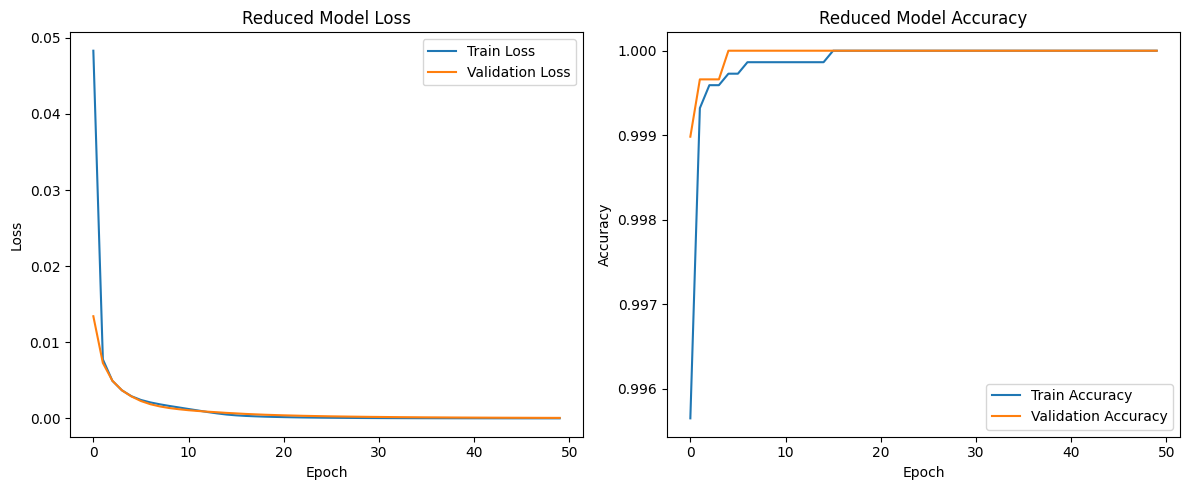

Saved reduced_training_curves.png


In [16]:
# ── 4. Plot Training Curves ───────────────────────────────────
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_reduced.history['loss'], label='Train Loss')
plt.plot(history_reduced.history['val_loss'], label='Validation Loss')
plt.title('Reduced Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_reduced.history['accuracy'], label='Train Accuracy')
plt.plot(history_reduced.history['val_accuracy'], label='Validation Accuracy')
plt.title('Reduced Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(f"{project_path}/output/reduced_training_curves.png", dpi=150)
plt.show()

print("Saved reduced_training_curves.png")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Reduced Model Classification Report:

              precision    recall  f1-score   support

  STATIONARY       1.00      1.00      1.00      1560
     WALKING       1.00      1.00      1.00      1387

    accuracy                           1.00      2947
   macro avg       1.00      1.00      1.00      2947
weighted avg       1.00      1.00      1.00      2947



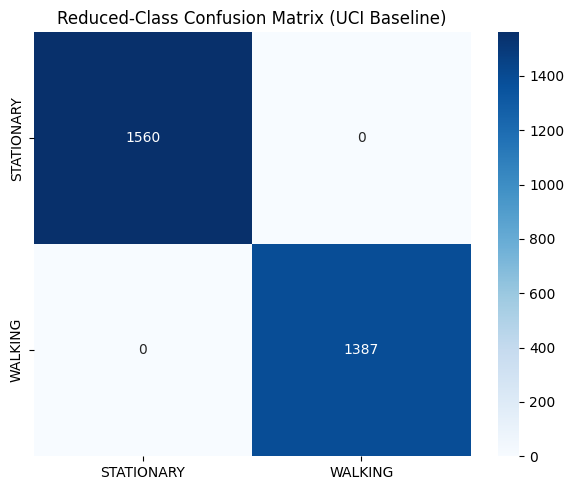

Saved reduced_confusion_matrix.png


In [17]:
# ── 5. Evaluation ─────────────────────────────────────────────
y_pred_reduced = np.argmax(model_reduced.predict(X_test_sc), axis=1)

print("\nReduced Model Classification Report:\n")
print(classification_report(y_test_mapped, y_pred_reduced, target_names=TARGET_NAMES_REDUCED))

cm_reduced = confusion_matrix(y_test_mapped, y_pred_reduced)

plt.figure(figsize=(6,5))
sns.heatmap(cm_reduced, annot=True, fmt="d",
            xticklabels=TARGET_NAMES_REDUCED,
            yticklabels=TARGET_NAMES_REDUCED,
            cmap="Blues")

plt.title("Reduced-Class Confusion Matrix (UCI Baseline)")
plt.tight_layout()
plt.savefig(f"{project_path}/output/reduced_confusion_matrix.png", dpi=150)
plt.show()

print("Saved reduced_confusion_matrix.png")

In [22]:
# ── 6. Save Model ─────────────────────────────────────────────
model_reduced.save(f"{project_path}/output/models/uci_har_reduced_baseline.keras")
print("Saved uci_har_reduced_baseline.keras")

Saved uci_har_reduced_baseline.keras
